In [236]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [237]:
sx = qt.sigmax()
sz = qt.sigmaz()

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

def coef_alpha_lz(t):
    return 0.5 - t

def coef_alpha_lsz(t, args):
    tw = args['t_wait']
    if (t < 0.5):
        coeff =  0.5 - t
    elif (t > tw + 0.5):
        coeff = 0.5 - (t-tw)
    else:
        coeff = 0
    return coeff


def H_qutip_LZ(epsilon, alpha):
    H_epsilon = 0.5*epsilon*sx
    H_alpha = alpha*sz

    H = [H_epsilon, [H_alpha, coef_alpha_lz]]

    return H

def H_qutip_LSZ(epsilon, alpha):
    H_epsilon = 0.5*epsilon*sx
    H_alpha = alpha*sz

    H = [H_epsilon, [H_alpha, coef_alpha_lsz]]

    return H

def H_numpy_lz(a, e, t):
    sz = np.array([[1,0],[0,-1]])
    sx = np.array([[0,1],[1,0]])
    Hx = a*sx + e*sz
    Hz = e*sz
    H = t*Hz + (0.5 - t)*Hx
    return H

def H_numpy_lsz(a, e, t, tw):
    sz = np.array([[1,0],[0,-1]])
    sx = np.array([[0,1],[1,0]])
    args = {'t_wait':tw}
    a = a*coef_alpha_lsz(t, args)
    Hx = a*sx
    Hz = 0.5*e*sz
    H = Hz + Hx
    return H

In [238]:
def H_numpy_lz(a, e, t):
    # Correct Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    
    Hx = a*sigma_x + e*sigma_z  # Constant term
    Hz = e*sigma_z              # Time-dependent coefficient
    H = t*Hz + (0.5 - t)*Hx
    return H

def H_numpy_lsz(a, e, t, tw):
    # Correct Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # Match the QuTiP structure
    coeff = coef_alpha_lsz(t, {'t_wait': tw})
    H = 0.5*e*sigma_x + a*coeff*sigma_z
    return H

def H_qutip_LSZ(epsilon, alpha):
    # This matches H_numpy_lsz_corrected structure
    H_epsilon = 0.5*epsilon*qt.sigmax()
    H_alpha = alpha*qt.sigmaz()
    H = [H_epsilon, [H_alpha, coef_alpha_lsz]]
    return H

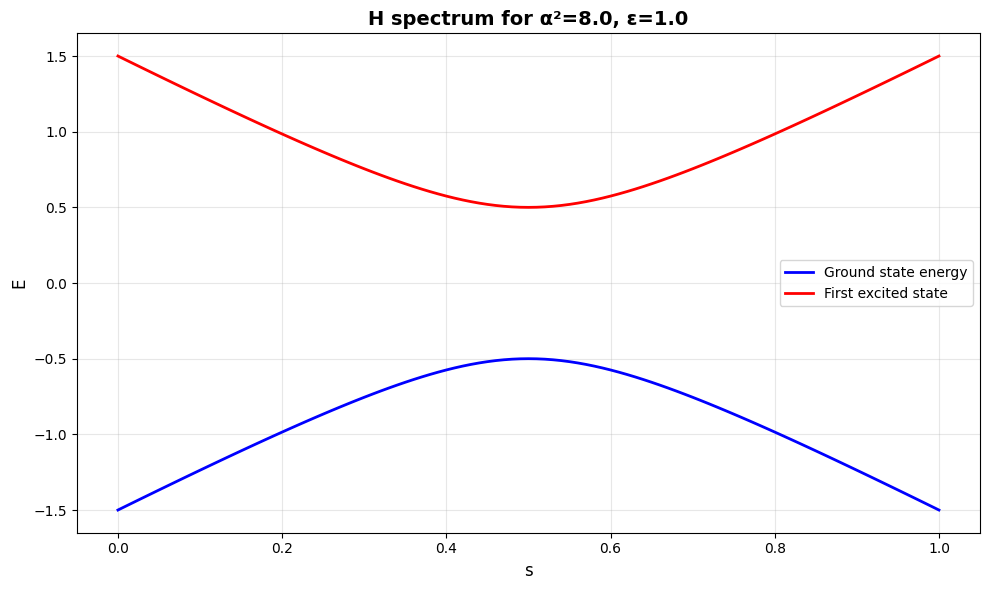

In [239]:
alpha = np.sqrt(8)
epsilon = 1
t_list = np.linspace(0, 1, 101)
g, e = [], []

for t in t_list:
    Ham = H_numpy_lz(alpha, epsilon, t)
    eigvals, eigvecs = np.linalg.eigh(Ham)
    g.append(eigvals[0])
    e.append(eigvals[1])

# Create plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(t_list, g, label='Ground state energy', linewidth=2, color='blue', linestyle='-')
plt.plot(t_list, e, label='First excited state', linewidth=2, color='red', linestyle='-')

# Customize
plt.title(f'H spectrum for α²={alpha**2:.1f}, ε={epsilon:.1f}', fontsize=14, fontweight='bold')
plt.xlabel('s', fontsize=12)
plt.ylabel('E', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show
plt.tight_layout()
plt.show()

In [255]:
epsilon = 1
alpha_list = np.linspace(0, 10, 101)
ti = 0
tf = 1
nsteps = 1001
times = np.linspace(ti, tf, nsteps)

pc, pe = [], []

for alpha in alpha_list:

    H_i = H_numpy_lz(alpha, epsilon, 0)
    eigvals_i, eigvecs_i = np.linalg.eigh(H_i)

    H_f = H_numpy_lz(alpha, epsilon, 1)
    eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

    psi0 = eigvecs_i[0][0]*ket0 + eigvecs_i[0][1]*ket1

    H = H_qutip_LZ(epsilon, alpha)

    result = qt.sesolve(H, psi0, times)

    final_state = result.states[-1]

    dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
    dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])
    pc.append(dot_c*dot_c.conj())
    pe.append(dot_e*dot_e.conj())

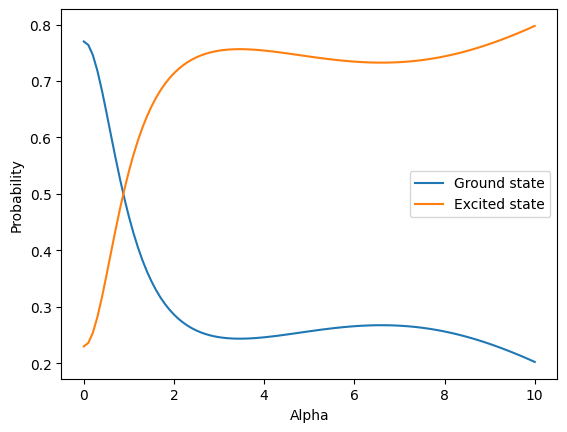

In [256]:
#print((np.log(pe)[-1] - np.log(pe)[0]) / ((1/alpha_list)[-1] - (1/alpha_list)[0]))
plt.plot(alpha_list, pc, label="Ground state")
plt.plot(alpha_list, pe, label="Excited state")
plt.xlabel('Alpha')
plt.ylabel('Probability')
plt.legend()

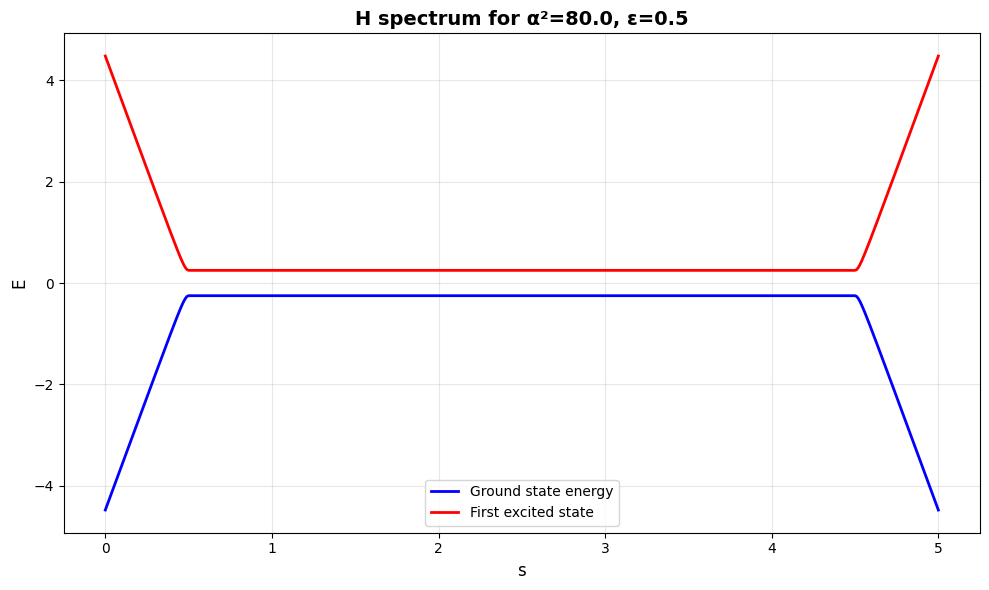

In [242]:
alpha = np.sqrt(80)
epsilon = 0.5
ti = 0
tf = 1
t_wait = 4
dt = 1e-2

nsteps = int((tf+t_wait)/dt)
t_list = np.linspace(ti, tf+t_wait, nsteps)

g, e = [], []

for t in t_list:
    Ham = H_numpy_lsz(alpha, epsilon, t, t_wait)
    eigvals, eigvecs = np.linalg.eigh(Ham)
    g.append(eigvals[0])
    e.append(eigvals[1])

# Create plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(t_list, g, label='Ground state energy', linewidth=2, color='blue', linestyle='-')
plt.plot(t_list, e, label='First excited state', linewidth=2, color='red', linestyle='-')

# Customize
plt.title(f'H spectrum for α²={alpha**2:.1f}, ε={epsilon:.1f}', fontsize=14, fontweight='bold')
plt.xlabel('s', fontsize=12)
plt.ylabel('E', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show
plt.tight_layout()
plt.show()

In [245]:
epsilon = 2
alpha = np.sqrt(8)
ti = 0
tf = 1
t_wait_list = np.linspace(0, 12, 101)
dt = 1e-3

pc, pe = [], []

H_i = H_numpy_lz(alpha, epsilon, 0)
eigvals_i, eigvecs_i = np.linalg.eigh(H_i)

H_f = H_numpy_lz(alpha, epsilon, 1)
eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

psi0 = eigvecs_i[0][0]*ket0 + eigvecs_i[0][1]*ket1

for tw in t_wait_list:

    nsteps = int((tf+tw)/dt)

    times = np.linspace(ti, tf+tw, nsteps)

    H = H_qutip_LSZ(epsilon, alpha)

    result = qt.sesolve(H, psi0, times, args={'t_wait': tw})

    final_state = result.states[-1]

    dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
    dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])
    pc.append(dot_c*dot_c.conj())
    pe.append(dot_e*dot_e.conj())

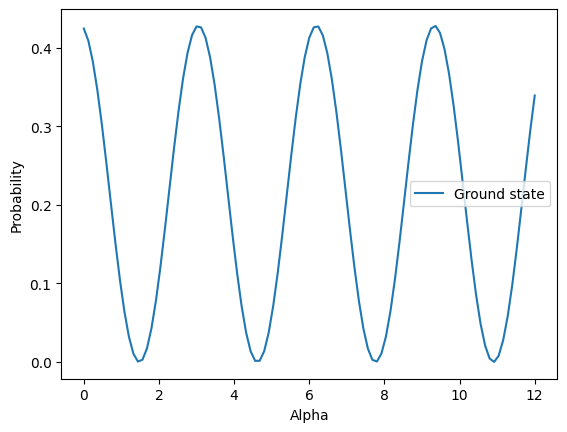

In [246]:
plt.plot(t_wait_list, pc, label="Ground state")
#plt.plot(alpha_list, pe, label="Excited state")
plt.xlabel('Alpha')
plt.ylabel('Probability')
plt.legend()